## Provide overview of results

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Tuple
from my_utils import LABELING_FUNCTION_2_PAPER_NAME

import glob
import os

In [1]:
# import functions from Scripts/plot.py and Scripts/8_make_results_plots.py
from Scripts.make_results_plots import plot_all_labeling_functions, plot_all_task_groups, plot_all_task_group_box_plots, plot_radar_chart

In [4]:
## check if folder "Results_Paper" exists, if not create it
if not os.path.exists("../Results_Paper_new"):
    os.makedirs("../Results_Paper_new")

In [5]:
#phecodes of interest (change if wanted)
phecodes_disease_onset = ['phecode_RE_468', 'phecode_CV_404.1', 'phecode_MS_705.1', 'phecode_MS_718', 'phecode_RE_474', 'phecode_CV_431.11', 'phecode_CV_440.3', 'phecode_EM_202', 'phecode_GU_582.2', 'phecode_MB_284', 'phecode_CV_410.2', 'phecode_CV_413.11', 'phecode_CV_438.11', 'phecode_DE_664.4', 'phecode_CV_404', 'phecode_NS_324.11', 'phecode_CV_400', 'phecode_CV_413.21', 'phecode_CV_416.21', 'phecode_CV_420', 'phecode_BI_164', 'phecode_CV_401', 'phecode_CV_424']
disease_name_disease_onset = [
    "Pneumonia",
    "Myocardial infarction [Heart attack]",
    "Rheumatoid arthritis",
    "Back pain",
    "Chronic obstructive pulmonary disease [COPD]",
    "Cerebral infarction [Ischemic stroke]",
    "Pulmonary embolism",
    "Diabetes mellitus",
    "Chronic kidney disease",
    "Suicide ideation and attempt or self harm",
    "Endocarditis",
    "Mitral valve insufficiency",
    "Abdominal aortic aneurysm",
    "Psoriasis",
    "Ischemic heart disease",
    "Parkinson's disease (Primary)",
    "Rheumatic fever and chronic rheumatic heart diseases",
    "Aortic stenosis",
    "Atrial fibrillation",
    "Cardiac arrest",
    "Anemia",
    "Hypertension",
    "Heart failure",
]

In [6]:
### Adapt the following parameters if necessary
allmodels = True #False #set to True if results should be shown for all models (including LLM2Vec and Qwen2), False if only Qwen3, CLMBR and Counts

In [7]:
indications = dict(
    disease_onset = disease_name_disease_onset,
    hospitalization = ["hospitalization"],#["OMOP_9201"], #["admin_hospital"],
    death = ["death"]#["OMOP_4306655"] #["admin_death"]
)

dataset = 'bigdataset' #'bigdataset' #'rawdataset' #


In [8]:
all_scores = []

# Calculate global min and max for y-axis
global_min = float('inf')
global_max = float('-inf')

num_cv_rounds = 5

# Loop through diseases and cases to load CSVs and find min/max
for indication, phecodelist in indications.items():
    for disease in phecodelist:
            #scores_filename = f"../tables/table_{case}_{disease}_nocalcembed_*.csv"
            scores_filename = f"./Results_new/{disease}_all_results.csv"
            matching_files = glob.glob(scores_filename)
            
            if(len(matching_files) == 0):
                print(f"Skipping {disease}")
                continue
            # Load the CSV#
            scores = pd.read_csv(matching_files[0], index_col=0)
            all_scores.append(scores)

all_scores = pd.concat(all_scores)

## rename sub_task - name everything disease_onset except hospitalization and death
all_scores['sub_task'] = all_scores['sub_task'].apply(lambda x: 'disease_onset' if x not in ['hospitalization', 'death'] else 'OMOP_9201' if x == 'hospitalization' else 'OMOP_4306655')

#only keeps rows where crossval_iteration is between 0 and 4
all_scores

Skipping Myocardial infarction [Heart attack]
Skipping Rheumatoid arthritis
Skipping Back pain
Skipping Chronic obstructive pulmonary disease [COPD]
Skipping Cerebral infarction [Ischemic stroke]
Skipping Pulmonary embolism
Skipping Chronic kidney disease
Skipping Suicide ideation and attempt or self harm
Skipping Endocarditis
Skipping Mitral valve insufficiency
Skipping Abdominal aortic aneurysm
Skipping Psoriasis
Skipping Parkinson's disease (Primary)
Skipping Rheumatic fever and chronic rheumatic heart diseases
Skipping Aortic stenosis
Skipping Anemia
Skipping Heart failure
Skipping hospitalization


,labeling_function,sub_task,model,head,replicate,k,score,value,std,lower,mean,upper
0,Pneumonia,disease_onset,count,gbm,0,-1,auroc,0.728022,0.018161,0.693615,0.728422,0.763687
1,Pneumonia,disease_onset,count,gbm,0,-1,brier,0.004264,0.000176,0.003911,0.004263,0.004622
2,Pneumonia,disease_onset,count,gbm,0,-1,auprc,0.007750,0.001395,0.005895,0.008139,0.011265
3,Pneumonia,disease_onset,count,gbm,0,1,auroc,0.545084,0.014292,0.518008,0.545343,0.573934
4,Pneumonia,disease_onset,count,gbm,0,1,brier,0.143867,0.000936,0.142090,0.143852,0.145716
...,...,...,...,...,...,...,...,...,...,...,...,...
835,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,3,128,brier,0.239028,0.000047,0.238935,0.239027,0.239119
836,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,3,128,auprc,0.025943,0.008109,0.014317,0.027224,0.045255
837,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,4,128,auroc,0.780661,0.015073,0.751749,0.781156,0.811110
838,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,4,128,brier,0.208084,0.000277,0.207540,0.208072,0.208601


Skipping Operational Outcomes because no results for None


1it [00:00,  4.35it/s]


AssertionError: Full data not present in Operational Outcomes for auroc

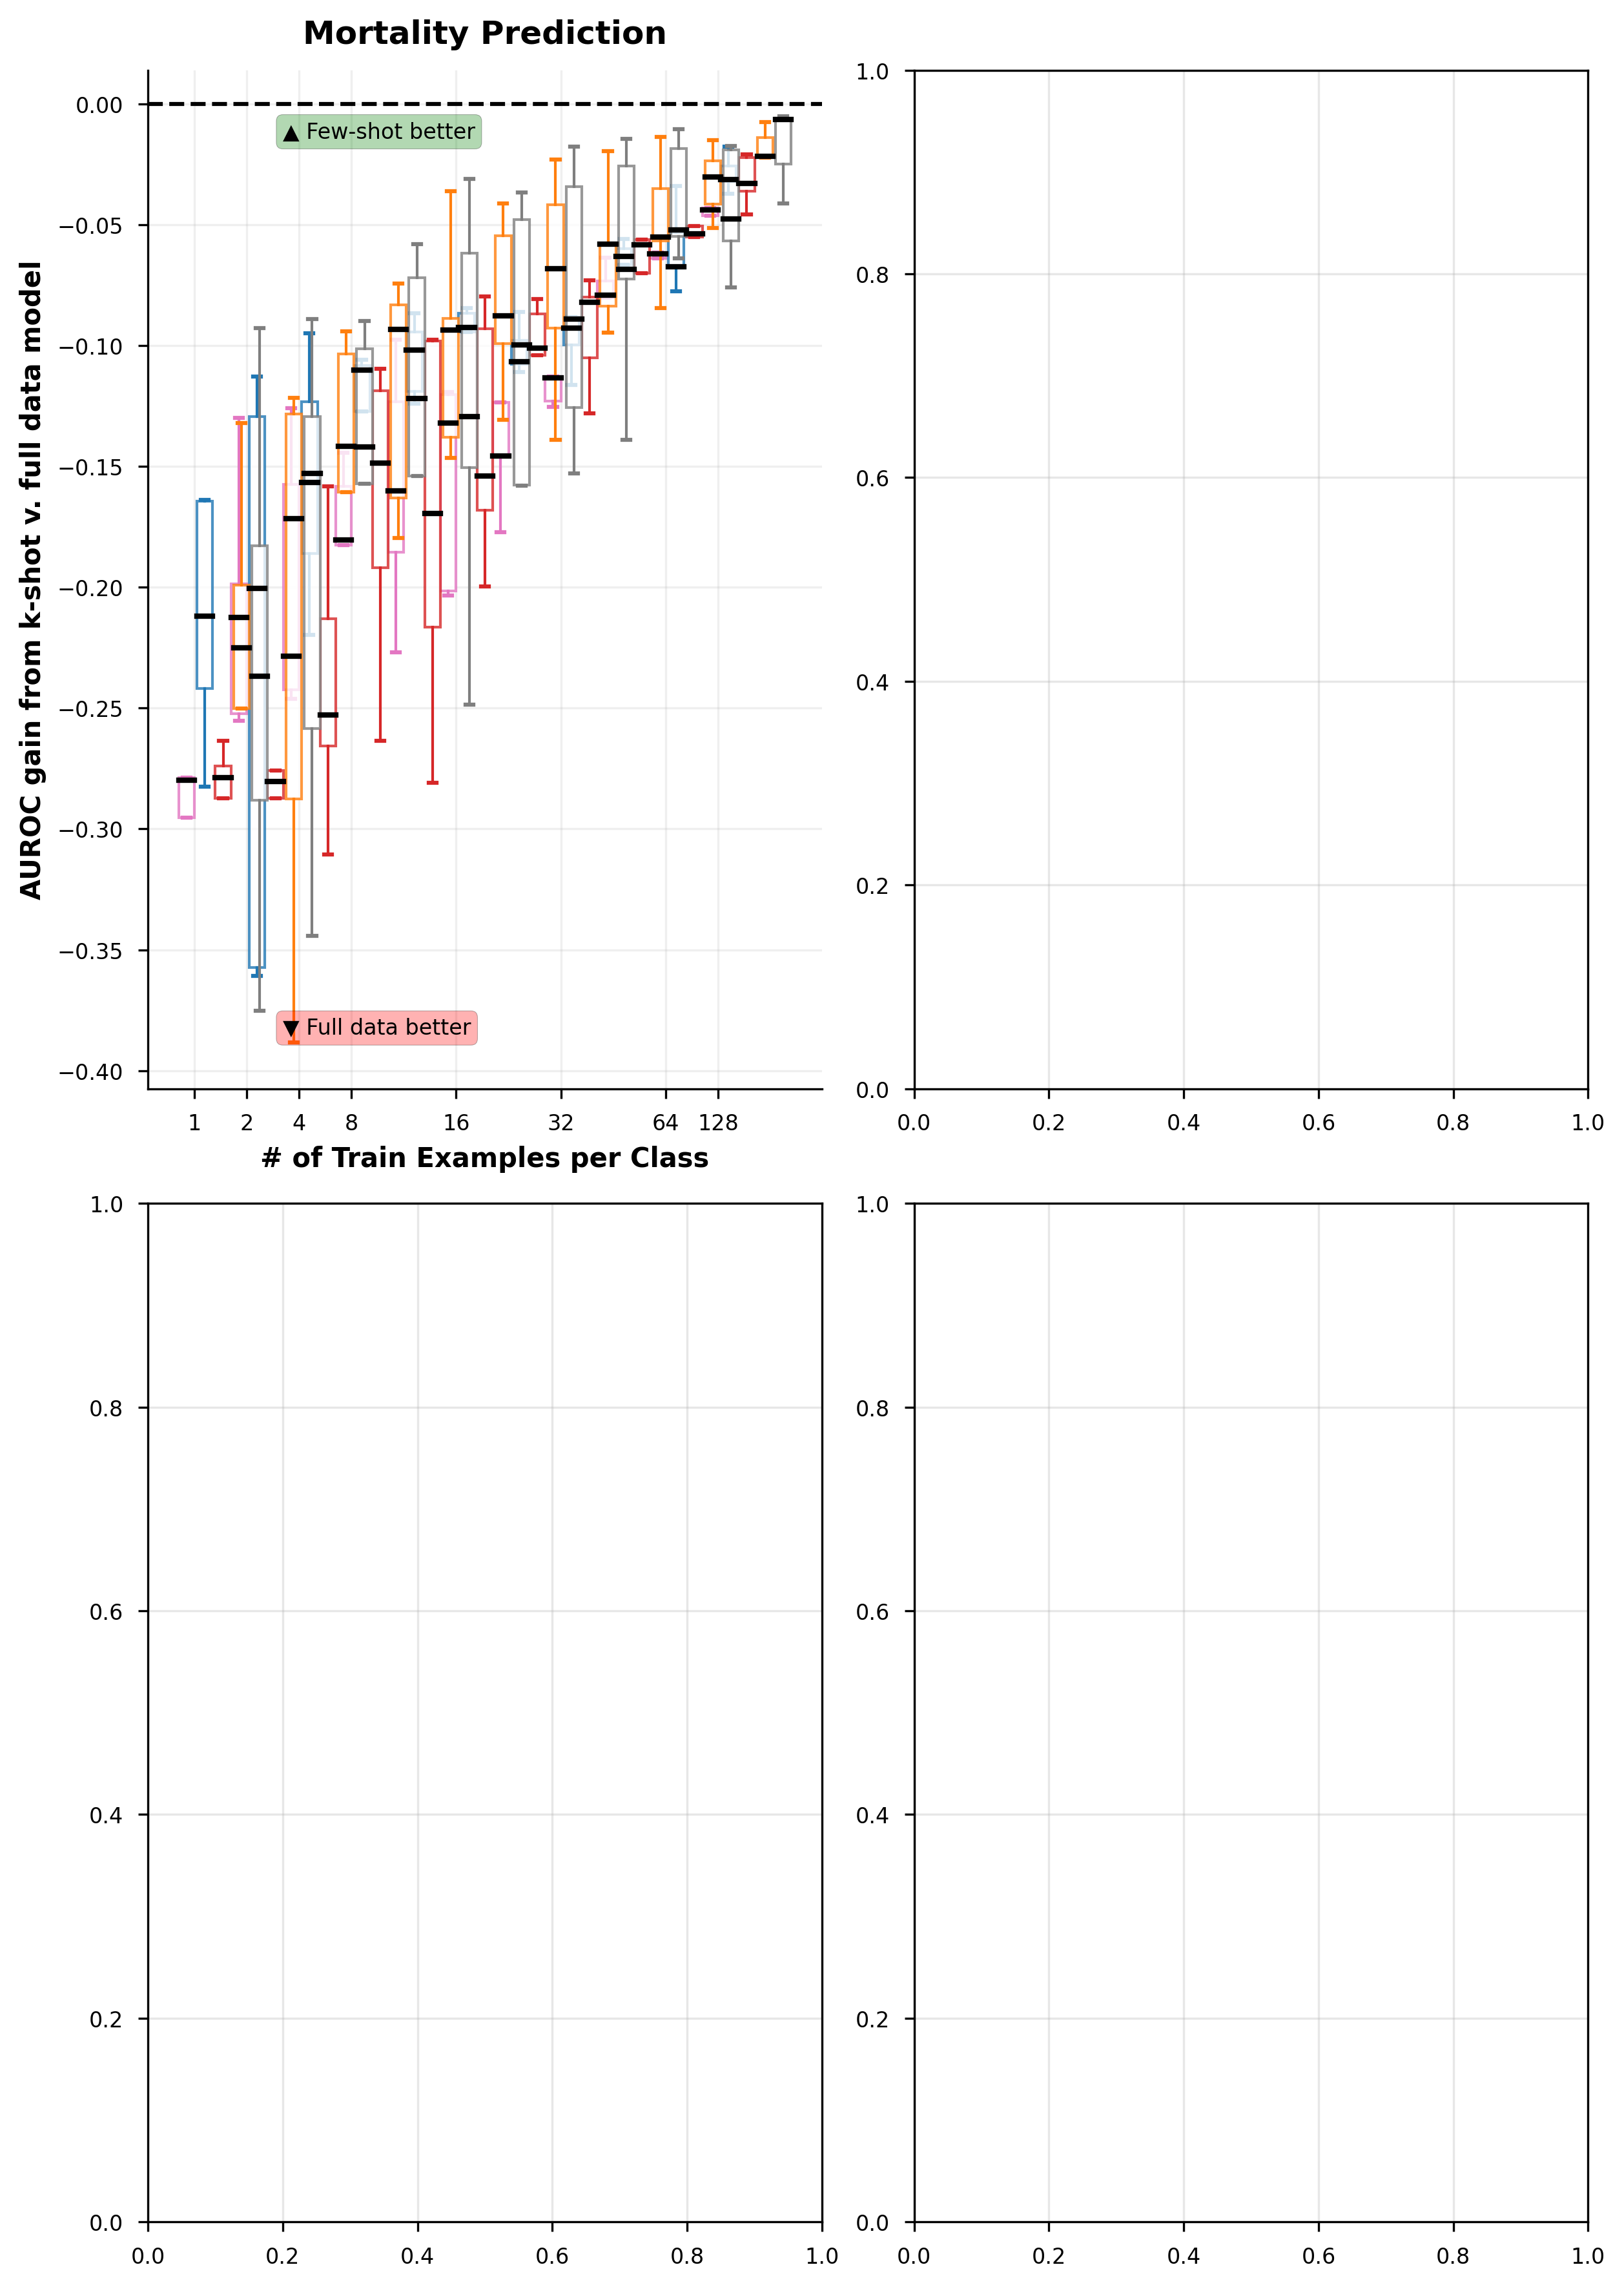

In [9]:
PATH_TO_OUTPUT_DIR = "./plots/"
os.makedirs(PATH_TO_OUTPUT_DIR, exist_ok=True)

MODEL_HEADS = None  # or specify e.g. [('clmbr','lr'), ('llm2vec','lr')]

# Individual task plots
plot_all_labeling_functions(
    all_scores,
    score="auroc",
    path_to_output_dir=PATH_TO_OUTPUT_DIR,
    model_heads=MODEL_HEADS,
    is_x_scale_log=True,
    is_std_bars=True
)

# Task group aggregated plots
plot_all_task_groups(
    all_scores,
    score="auroc",
    path_to_output_dir=PATH_TO_OUTPUT_DIR,
    model_heads=MODEL_HEADS,
    is_x_scale_log=True
)

# Boxplots
plot_all_task_group_box_plots(
    all_scores,
    score="auroc",
    path_to_output_dir=PATH_TO_OUTPUT_DIR,
    model_heads=MODEL_HEADS
)

# Radar plot for specific k
plot_radar_chart(
    all_scores,
    k=32,
    path_to_output_dir=PATH_TO_OUTPUT_DIR,
    score="auroc",
    model_heads=MODEL_HEADS
)

In [11]:
if not allmodels:
    model_name = {
        "qwen": "GTE-Qwen2-7B+LR",
        "qwen3": "Qwen3-Emb-8B+LR",
        "llm2vec": "LLM2Vec-Llama-3.1 8B+LR",
        "clmbr": "CLMBR+LR",
        "count": "Count-based+GBM",
    }
else:
    model_name = {
        "qwen": "GTE-Qwen2-7B+LR",
        "qwen3": "Qwen3-Emb-8B+LR",
        "llm2vec": "LLM2Vec-Llama-3.1 8B+LR",
        "clmbr": "CLMBR+LR",
        "count": "Count-based+GBM",
    }

# model_palette = {
#     "GTE-Qwen2-7B+LR": "#ad6627",           # brown
#     "Qwen3-Emb-8B+LR": "#ff7f0e",     # orange
#     "LLM2Vec-Llama-3.1 8B+LR": "#2ca02c",   # green
#     "CLMBR+LR": "#1f77b4",                  # blue
#     "Count-based+GBM": "#d62728",          # red
# }
model_palette = {
    "Qwen3-Emb-8B+LR": "#1f77b4",     # blue
    "CLMBR+LR": "#ff7f0e",                  # orange
    "Count-based+GBM": "#2ca02c",          # green
    "LLM2Vec-Llama-3.1 8B+LR": "#d62728",   # red
    "GTE-Qwen2-7B+LR": "#9467bd"           # purple
}

# Define different markers for each model
# model_markers = {
#     "CLMBR+LR": "X",
#     "Count-based+GBM": "p",
#     "GTE-Qwen2-7B+LR": "o",
#     "Qwen3-Emb-8B+LR": "o",
#     "LLM2Vec-Llama-3.1 8B+LR": "o"
# }
model_markers = {
    "Qwen3-Emb-8B+LR": "X",
    "CLMBR+LR": "o",
    "Count-based+GBM": "h",
    "LLM2Vec-Llama-3.1 8B+LR": "^", 
    "GTE-Qwen2-7B+LR": "*"      
}

task_mapping = {
    "disease_onset": "Assignment of New Diagnoses",
    "OMOP_9201": "Operational Outcomes",
    "OMOP_4306655": "Mortality Prediction",
}

selected_diseases = {"OMOP_4306655", "OMOP_9201"}

#legend_order = ["CLMBR+LR", "GTE-Qwen2-7B+LR", "Qwen3-Embedding-8B+LR", "LLM2Vec-Llama-3.1 8B+LR", "Count-based+GBM"]
if not allmodels:
    legend_order = ["Qwen3-Emb-8B+LR", "CLMBR+LR", "Count-based+GBM"]
else:
    legend_order = ["Qwen3-Emb-8B+LR", "CLMBR+LR", "Count-based+GBM", "LLM2Vec-Llama-3.1 8B+LR", "GTE-Qwen2-7B+LR"]


In [14]:
# -------------------------------------------------
# 1️⃣ Filter for AUROC and specific k
# -------------------------------------------------
k_value = 128   # choose 2 or 4

filtered_scores = (
    all_scores[
        (all_scores["score"] == "auroc") &
        (all_scores["k"] == k_value)
    ]
    .copy()
)

# Optional: rename models
filtered_scores["model"] = filtered_scores["model"].map(model_name)

# -------------------------------------------------
# 2️⃣ Aggregate over replicates
# -------------------------------------------------
agg = (
    filtered_scores
    .groupby(["model", "labeling_function"])
    .agg(
        mean=("mean", "mean"),
        std=("mean", "std"),
        count=("mean", "count"),
    )
    .reset_index()
)

# -------------------------------------------------
# 3️⃣ Compute 95% CI
# -------------------------------------------------
agg["sem"] = agg["std"] / np.sqrt(agg["count"])
agg["ci95"] = 1.96 * agg["sem"]
agg["ci_lower"] = agg["mean"] - agg["ci95"]
agg["ci_upper"] = agg["mean"] + agg["ci95"]

agg[["mean", "ci_lower", "ci_upper"]] = \
    agg[["mean", "ci_lower", "ci_upper"]].round(3)

# -------------------------------------------------
# 4️⃣ Create formatted string
# -------------------------------------------------
agg["auroc_formatted"] = agg.apply(
    lambda row: f"{row['mean']:.3f} ({row['ci_lower']:.3f}–{row['ci_upper']:.3f})",
    axis=1
)

# -------------------------------------------------
# 5️⃣ Order models
# -------------------------------------------------
model_order = list(model_name.values())
agg["model"] = pd.Categorical(
    agg["model"],
    categories=model_order,
    ordered=True
)

# -------------------------------------------------
# 6️⃣ Pivot table (models x labeling_functions)
# -------------------------------------------------
pretty_table = agg.pivot(
    index="model",
    columns="labeling_function",
    values="auroc_formatted"
)

# -------------------------------------------------
# 7️⃣ Mean across labeling_functions
# -------------------------------------------------
numerical_pivot = agg.pivot(
    index="model",
    columns="labeling_function",
    values="mean"
)

mean_across = numerical_pivot.mean(axis=1).round(3)

ci_data = agg.pivot_table(
    index="model",
    columns="labeling_function",
    values=["ci_lower", "ci_upper"]
)

avg_ci_lower = ci_data["ci_lower"].mean(axis=1).round(3)
avg_ci_upper = ci_data["ci_upper"].mean(axis=1).round(3)

mean_formatted = pd.DataFrame({
    f"Mean Across LFs (k={k_value})":
        [f"{m:.3f} ({l:.3f}–{u:.3f})"
         for m, l, u in zip(mean_across, avg_ci_lower, avg_ci_upper)]
}, index=mean_across.index)

pretty_table = pretty_table.join(mean_formatted)

# Ensure correct order
pretty_table = pretty_table.reindex(model_order)

pretty_table

/tmp/ipykernel_500138/1725606343.py:80: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ci_data = agg.pivot_table(


,Atrial fibrillation,Chronic kidney disease,Diabetes mellitus,Hypertension,Ischemic heart disease,Pneumonia,death,hospitalization,Mean Across LFs (k=128)
model,,,,,,,,,
GTE-Qwen2-7B+LR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Qwen3-Emb-8B+LR,0.810 (0.798–0.823),0.743 (0.737–0.749),0.673 (0.660–0.685),0.608 (0.594–0.621),0.707 (0.705–0.710),0.705 (0.698–0.713),0.784 (0.776–0.793),0.623 (0.609–0.637),0.707 (0.689–0.717)
LLM2Vec-Llama-3.1 8B+LR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLMBR+LR,0.808 (0.804–0.812),0.728 (0.723–0.733),0.626 (0.606–0.645),0.600 (0.587–0.614),0.725 (0.714–0.735),0.709 (0.698–0.721),0.772 (0.766–0.779),0.633 (0.623–0.643),0.700 (0.697–0.716)
Count-based+GBM,0.816 (0.812–0.820),0.735 (0.722–0.748),0.678 (0.657–0.699),0.619 (0.605–0.633),0.707 (0.694–0.720),0.693 (0.672–0.715),0.748 (0.739–0.757),0.626 (0.609–0.642),0.703 (0.690–0.710)
